# Simple GAN by fasion image Chapter 14 Workshop 1

## Check gpu

In [2]:
!nvidia-smi

Fri Jul 11 11:53:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.40                 Driver Version: 576.40         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   41C    P8              2W /  120W |     280MiB /   8188MiB |     23%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import module

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

from keras.datasets.fashion_mnist import load_data
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Conv2DTranspose 
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Flatten, Reshape, Dropout

from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


## Setting parameter

In [4]:
noise_dim = 100     # Dimension of the noise vector to seed the generator
batch_size = 64     # Batch size for training

epochs = 50         # Number of epochs to train the model

img_rows, img_cols, channels = 28, 28, 1  # Dimensions of the Fashion MNIST images

optimizer = Adam(0.0002, 0.5)  # Optimizer for training the GAN
np.random.seed(10)  # Set random seed for reproducibility

## Prepare data

### load all image

In [5]:
(x_train, y_train), (_, _) = load_data()

# Normalize the images to the range [-1, 1]
x_train = x_train.astype(np.float32) / 127.5 - 1.0

# Reshape the training data to match the input shape of the model
x_train = np.expand_dims(x_train, axis=-1)  # Add channel dimension

In [6]:
print(x_train.shape)
print('min max:', x_train.min(), x_train.max())

(60000, 28, 28, 1)
min max: -1.0 1.0


### reduce image class (3 classes from 10 classes)

In [7]:
n_samples = 6000
# x_train_backup = x_train.copy()
x_train = x_train[np.where(y_train < 3)[0]][:n_samples] # np.where(y_train < 3) is tuple

In [8]:
print(x_train.shape)

(6000, 28, 28, 1)


## check iteration

In [9]:
step_per_epoch = math.ceil(n_samples / batch_size)
print('number of batches:', step_per_epoch)

number of batches: 94


## Visualizaion data set

### define function

In [10]:
def visualize_images(images, n=10):
    """Visualize a grid of images."""
    plt.figure(figsize=(n, n))
    for i in range(n * n):
        plt.subplot(n, n, i + 1)
        plt.imshow(images[i].reshape(img_rows, img_cols), cmap='gray_r')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_images(noise, sizefig, generator):
    genereated_images = generator.predict(noise)
    plt.figure(figsize=(sizefig[1], sizefig[0]))
    
    for i, image in enumerate(genereated_images):
        plt.subplot(sizefig[0], sizefig[1], i + 1)
        if channels == 1:
            plt.imshow(image.reshape(img_rows, img_cols), cmap='gray_r')
        else:
            plt.imshow(image.reshape(img_rows, img_cols, channels))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### visualize

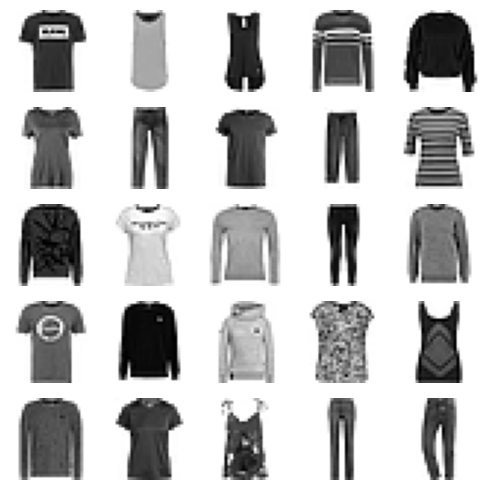

In [11]:
visualize_images(x_train, n=5)

## Create model

### define Model Generator 

In [12]:
# 3 layer [dense, reshape, conV2DTranspose, conV2DTranspose, conV2D] generator
# if output_dim = 28x28x1 <-- 28x28x64 <-- 14x14x128 <-- 7x7x128 <-- math(7*7*128) <-- input_dim = 100
def create_generator(output_dim):
    """Create the generator model."""
    generator_model = Sequential(name='generator')

    input_dimension = int(output_dim/2/2)
    
    # dense 
    generator_model.add(Dense((input_dimension**2)*128, input_dim=noise_dim))
    generator_model.add(LeakyReLU(alpha=0.2))
    # reshape
    generator_model.add(Reshape((input_dimension, input_dimension, 128)))

    # first transposed convolution
    generator_model.add(Conv2DTranspose(128, (4,4), strides=2, padding='same'))
    generator_model.add(LeakyReLU(alpha=0.2))
    # seond transposed convolution
    generator_model.add(Conv2DTranspose(64, (4,4), strides=2, padding='same'))
    generator_model.add(LeakyReLU(alpha=0.2))
    # final transposed convolution
    generator_model.add(Conv2D(channels, (3,3),padding='same', activation='tanh'))
    
    generator_model.compile(loss='binary_crossentropy', optimizer=optimizer)
    
    return generator_model

### define Model Discriminator 

In [13]:
def create_discriminator():
    """Create the discriminator model."""
    discriminator_model = Sequential(name='discriminator')

    # first convolution
    discriminator_model.add(Conv2D(64, (3,3), padding='same', input_shape=(img_rows, img_cols, channels)))
    discriminator_model.add(LeakyReLU(alpha=0.2))
    # second convolution
    discriminator_model.add(Conv2D(128, (3,3), strides=2, padding='same'))
    discriminator_model.add(LeakyReLU(alpha=0.2))
    
    # flatten and dense layer
    discriminator_model.add(Flatten())
    discriminator_model.add(Dropout(0.4))
    discriminator_model.add(Dense(1, activation='sigmoid'))

    discriminator_model.compile(loss='binary_crossentropy', optimizer=optimizer)
    
    return discriminator_model

### create model

In [18]:
discriminator = create_discriminator()
discriminator.trainable = False  # Freeze the discriminator during generator training

generator = create_generator(28) # Output dimension is 28x28x1

# GAN model combines generator and discriminator
gan_input = Input(shape=(noise_dim,))
fake_image = generator(gan_input)
gan_output = discriminator(fake_image)

# Create the GAN model
gan = Model(gan_input, gan_output, name='gan')
gan.compile(loss='binary_crossentropy', optimizer=optimizer)

In [19]:
generator.summary()
discriminator.summary()
gan.summary()

Model: "generator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 6272)              633472    
                                                                 
 leaky_re_lu_7 (LeakyReLU)   (None, 6272)              0         
                                                                 
 reshape_1 (Reshape)         (None, 7, 7, 128)         0         
                                                                 
 conv2d_transpose_2 (Conv2DT  (None, 14, 14, 128)      262272    
 ranspose)                                                       
                                                                 
 leaky_re_lu_8 (LeakyReLU)   (None, 14, 14, 128)       0         
                                                                 
 conv2d_transpose_3 (Conv2DT  (None, 28, 28, 64)       131136    
 ranspose)                                               

## Visualize first image from generator

1/1 [==============================] - 0s 8ms/step


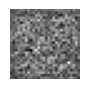

In [21]:
noise = np.random.normal(0, 1, size=(1, noise_dim))  # Generate random noise for visualization
image = generator.predict(noise)  # Generate an image from the noise
visualize_images(image, n=1)  # Visualize the generated image

## Train GAN

In [ ]:
from tqdm import tqdm
# Training the GAN
for epoch in range(epochs):
    for step in tqdm(range(step_per_epoch)):
        # Generate random noise
        noise = np.random.normal(0, 1, size=(batch_size, noise_dim))
        
        # Generate fake images
        fake_x = generator.predict(noise)
        
        # Get a batch of real images
        real_x = x_train[np.random.randint(0, x_train.shape[0], batch_size)]
        
        # Concatenate real and fake images
        x = np.concatenate([real_x, fake_x])

        # Create labels for real and fake images
        disc_y = np.zeros(2 * batch_size)
        disc_y[:batch_size] = 0.9

        # Train the discriminator
        d_loss = discriminator.train_on_batch(x, disc_y)

        y_gen = np.ones(batch_size)
        # Train the generator
        g_loss = gan.train_on_batch(noise, y_gen)

        if(epoch==0 and step == 0):
            print(f"noise shape: {np.random.normal(0, 1, size=(batch_size, noise_dim)).shape}")
            print(f"fake_x shape: {fake_x.shape}")
            print(f"real_x shape: {real_x.shape}")
            print(f"x shape: {x.shape}")
            print(f"disc_y shape: {disc_y.shape}")
            print(f"y_gen shape: {y_gen.shape}")

    print(f'Step {step + 1}/{step_per_epoch}, D Loss: {d_loss:.4f}, G Loss: {g_loss:.4f}')
    if (epoch + 1) % 10 == 0:
        # show_images(noise_gan[:16], (4, 4), generator)  # Show generated images every 10 epochs
        dsp_img = (3,5)
        noise_gan = np.random.normal(0, 1, size=(dsp_img[0]*dsp_img[1], noise_dim))
        show_images(noise_gan, dsp_img, generator)  # Show generated images

2/2 [==============================] - 0s 29ms/step


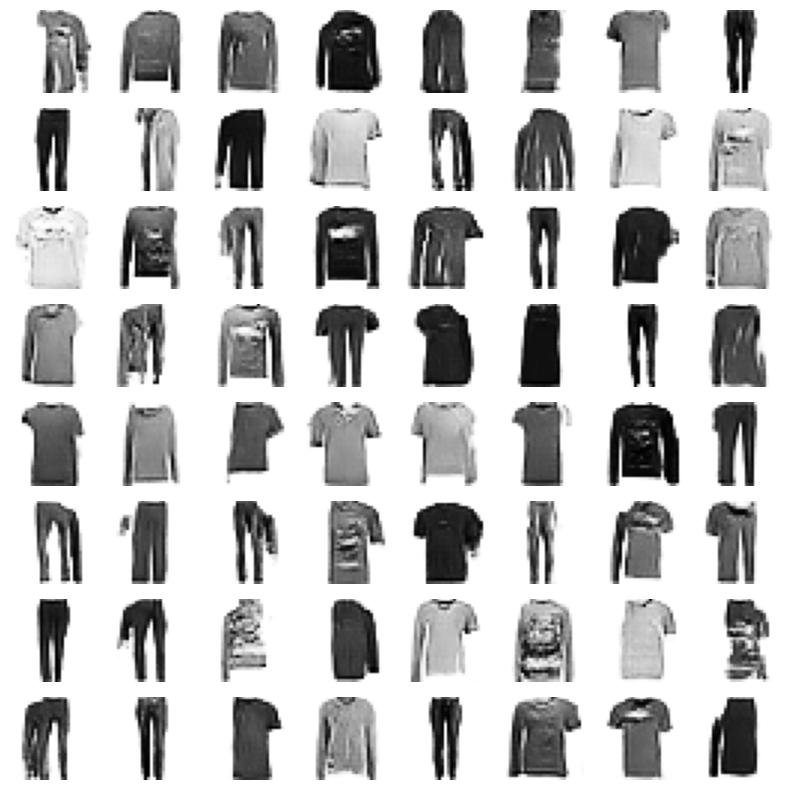

In [27]:
noise = np.random.normal(0, 1, size=(64, noise_dim))  # Generate random noise for final visualization
show_images(noise, (8, 8), generator)  # Visualize the final generated images